

**Objective:**
1. Understand unKnown's (Company name is unKnown) specific data through EDA.
2. Build a machine learning model (LightGBM) to identify key drivers.
3. Validate key drivers through statistical hypothesis testing.
4. Simulate the impact of proposed interventions to quantify potential savings.

##Introduction & Market Analysis

###Company Context
"unKnown" is an IT consulting firm facing challenges with employee retention.
We have a dataset containing historical data of employees, including their attrition status.

### 1.2 Market Analysis (IT Industry Trends)
[High Turnover](https://business.talkspace.com/articles/tech-industry-turnover-rate#:~:text=The%20tech%20industry%20turnover%20rate,in%20you%20and%20your%20brand): The IT/tech sector consistently experiences high employee churn. Recent analyses show annual attrition rates in tech ranging from roughly 13% up to 21%, which is higher than many other industries.

[Cost of Attrition](https://helloteam.com/average-turnover-rates-by-industry-2021-22/#:~:text=financially%20because%20of%20the%20high,2x%20their%20salary): Losing employees is extremely costly. Studies estimate that replacing a skilled IT professional often costs about 1.5 to 2 times the person's annual salary when accounting for recruitment, training, and lost productivity.

[Key Attrition Drivers](https://info.workinstitute.com/hubfs/2024%20Retention%20Report/Work%20Institute%202024%20Retention%20Report.pdf#:~:text=emerging%20workforce,7.%20Total%20Rewards%3A%209.1): Understanding why employees leave is crucial. Industry surveys identify several top drivers of attrition in tech. A lack of career growth or advancement opportunities is frequently cited - for example, about one-third of employees who quit report limited growth as a primary reason. Poor work-life balance leading to burnout is another major factor; nearly 41% of employees report experiencing burnout, which contributes to higher turnover. Finally, compensation issues (e.g. uncompetitive pay or benefits) consistently rank among the leading reasons people seek other jobs. Addressing these core issues - growth, work-life balance, and pay - is essential for improving retention.

![Market Analysis](https://drive.google.com/uc?id=1ILucoAw2UFQqKcZEa6_lfPEcABEocwa4)

---

##Setup and Data Loading

###Import libraries
First, we import the necessary libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
import lightgbm as lgb

# Set plot style
sns.set(style="whitegrid")

###Connect with Google Drive
To load the data, we first need to connect this Colab notebook with Google Drive.

In [ ]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path

# Automatically get the current working directory
current_dir = Path(os.getcwd())

# Define file paths using pathlib
file_path = current_dir / "drive" / "MyDrive" / "GCI"  / "dataset" / "data.csv"

# Check if path exists
if file_path.exists():
    print("The file exist and path is correctly set.")
else:
    print("The file is missing or path is not correctly set.")

The file exist and path is correctly set.


Let's display the data.

In [ ]:
# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


---

##Exploratory Data Analysis (EDA)

EDA is crucial for understanding the structure and quality of the data.

In [ ]:
# Check dataset shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check data types and missing values
print("\nDataset Info:")
df.info()

The dataset has 1470 rows and 44 columns.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel             

###Target Variable Analysis

The target variable is `Attrition`. Let's look at its distribution.

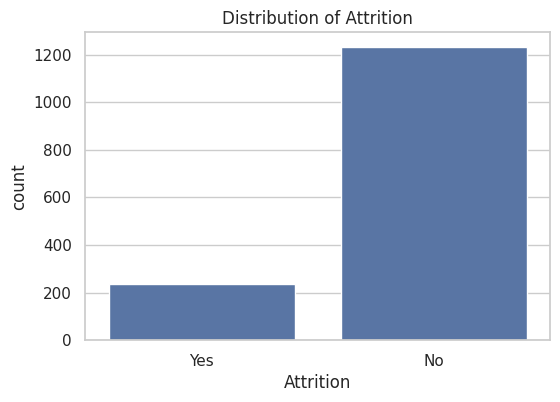

Attrition Rate:
Attrition
No     83.809524
Yes    16.190476
Name: proportion, dtype: float64


In [ ]:
# Visualize Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df)
plt.title('Distribution of Attrition')
plt.show()

# Calculate Attrition Rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate:")
print(attrition_rate)

###Feature Analysis & Correlation with Attrition

Now let's explore the relationship between various features and employee attrition. Understanding which factors are associated with higher attrition rates is crucial for developing targeted retention strategies.

We will analyze:
- **Numerical Features**: How distributions of age, income, experience, and satisfaction metrics differ between employees who left vs. those who stayed
- **Categorical Features**: How attrition rates vary across different departments, job roles, business travel frequencies, etc.

### Visualizing Numerical Features

Let's visualize the distribution of numerical features.

Total numerical features to plot: 33
Skipped 2 constant columns


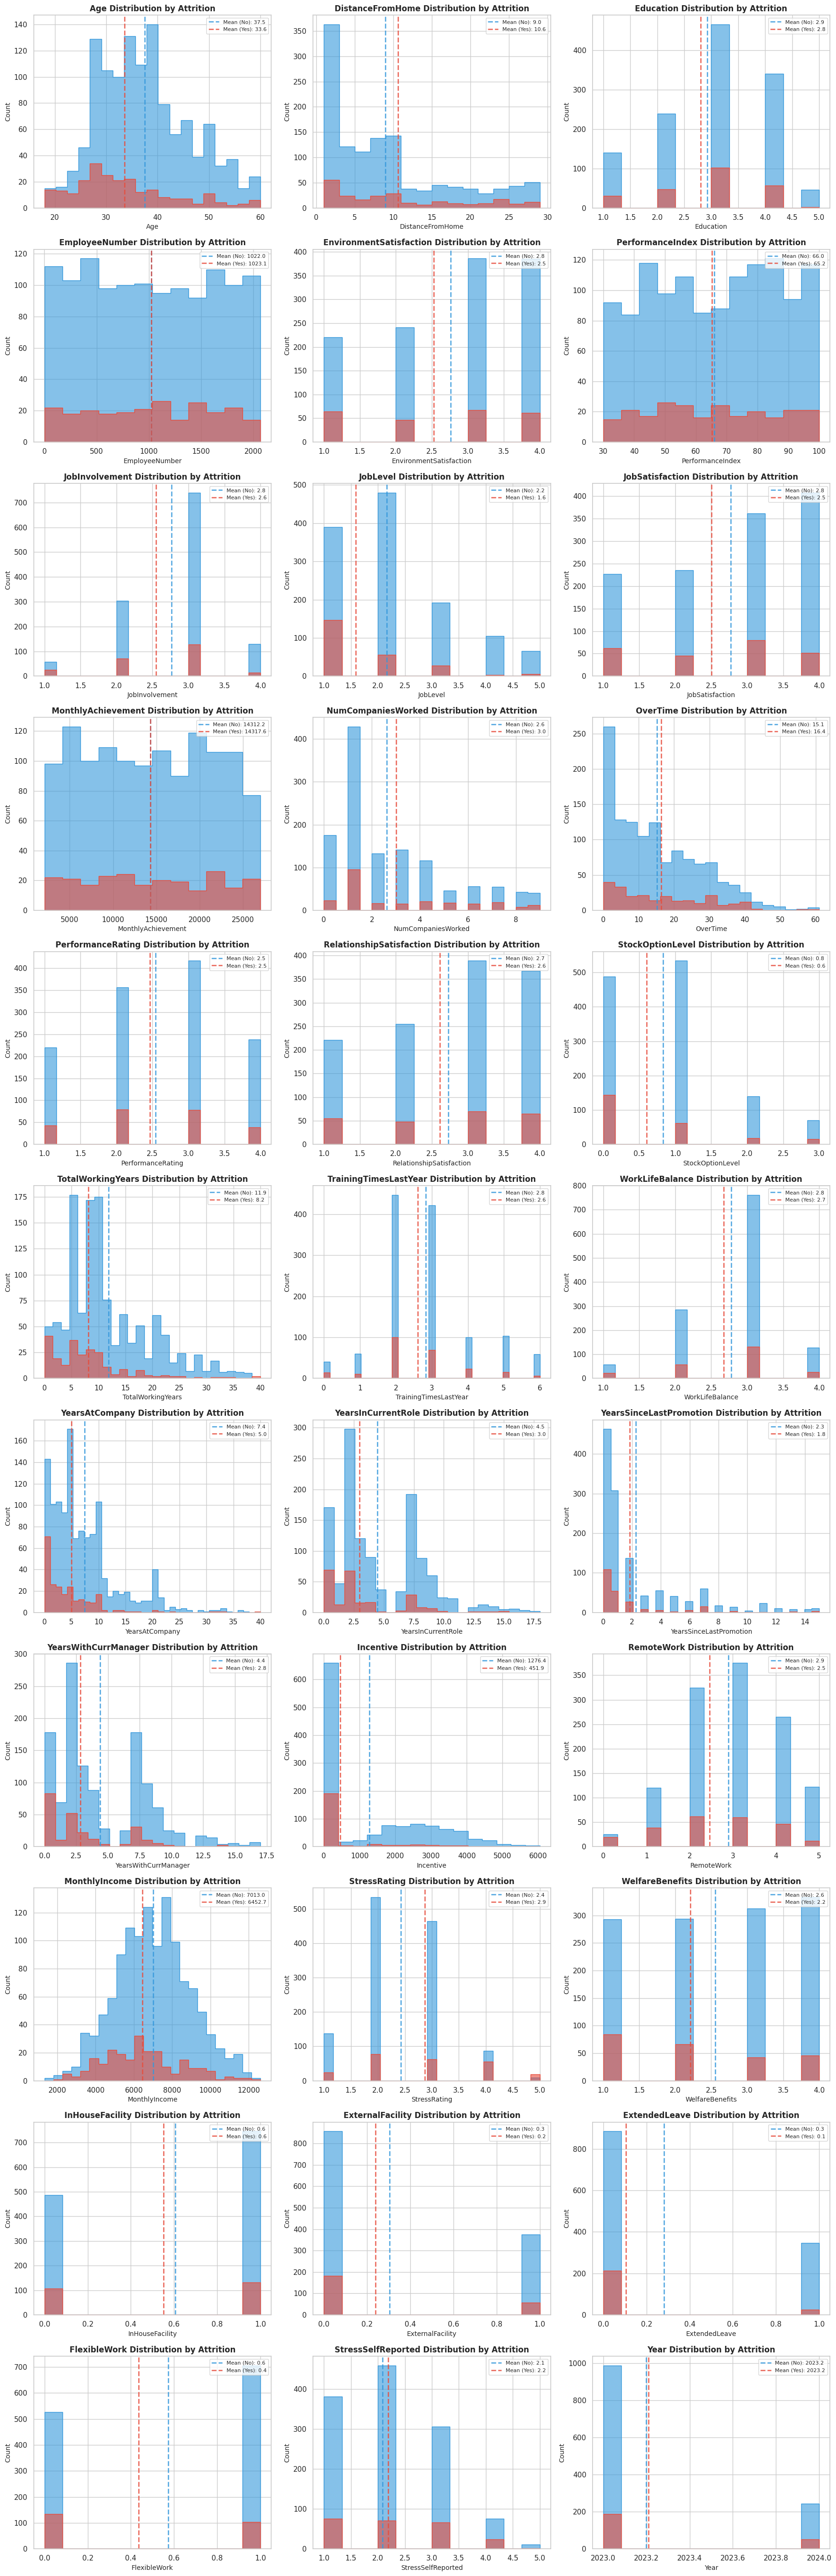

In [ ]:
# Select ALL numerical columns (excluding target)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Attrition' in num_cols:
    num_cols.remove('Attrition')

# Filter out constant columns (zero variance) as they can't be visualized meaningfully
cols_to_plot = [col for col in num_cols if df[col].nunique() > 1]

print(f'Total numerical features to plot: {len(cols_to_plot)}')
print(f'Skipped {len(num_cols) - len(cols_to_plot)} constant columns')

# Calculate grid size
n_cols_to_plot = len(cols_to_plot)
n_rows = math.ceil(n_cols_to_plot / 3)
n_cols_grid = min(3, n_cols_to_plot)

# Plot configurations
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(18, n_rows * 5))

# Flatten axes if it's 2D
if n_cols_to_plot == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.flatten()

# Plot numerical features by Attrition with mean lines
for i, col in enumerate(cols_to_plot):
    # Calculate means for each group
    mean_no = df[df['Attrition'] == 'No'][col].mean()
    mean_yes = df[df['Attrition'] == 'Yes'][col].mean()

    sns.histplot(data=df, x=col, hue='Attrition', hue_order=['Yes', 'No'], kde=False, element='step',
                    ax=axes[i], palette=['#e74c3c', '#3498db'], alpha=0.6)

    # Add vertical lines for means
    axes[i].axvline(mean_no, color='#3498db', linestyle='--', linewidth=2, alpha=0.8,
                    label=f'Mean (No): {mean_no:.1f}')
    axes[i].axvline(mean_yes, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8,
                    label=f'Mean (Yes): {mean_yes:.1f}')

    axes[i].set_title(f'{col} Distribution by Attrition', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(fontsize=8, loc='upper right')

    # Ensure legend order matches visual: No (blue) first, then Yes (red)
    handles, labels = axes[i].get_legend_handles_labels()
    # Reorder to ensure No comes before Yes
    if len(labels) >= 2:
        # Check current order and swap if needed
        if labels[0] == 'Yes':
            handles = [handles[1], handles[0]]
            labels = [labels[1], labels[0]]
        axes[i].legend(handles, labels, fontsize=8, loc='upper right')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Insights from Numerical Features:

Analysis of all numerical variables reveals significant patterns between employees who left vs. those who stayed:

**Top Differentiating Factors:**

**1. Compensation & Recognition (Largest Impact):**
- **Incentive**: 65% lower for departed employees (\$452 vs \$1,276)
- **Stock Options**: 28% lower for those who left
- **Monthly Income**: Departed employees earned less overall
- Financial incentives are critical for retention

**2. Benefits & Work Flexibility:**
- **Extended Leave**: 63% lower availability among departed employees
- **Flexible Work**: 24% lower for those who left
- **Remote Work**: 15% less remote work opportunities
- **External Facilities**: 21% lower access
- Work-life benefits significantly impact retention

### Visualizing Categorical Features

Let's visualize the distribution of categorical features.

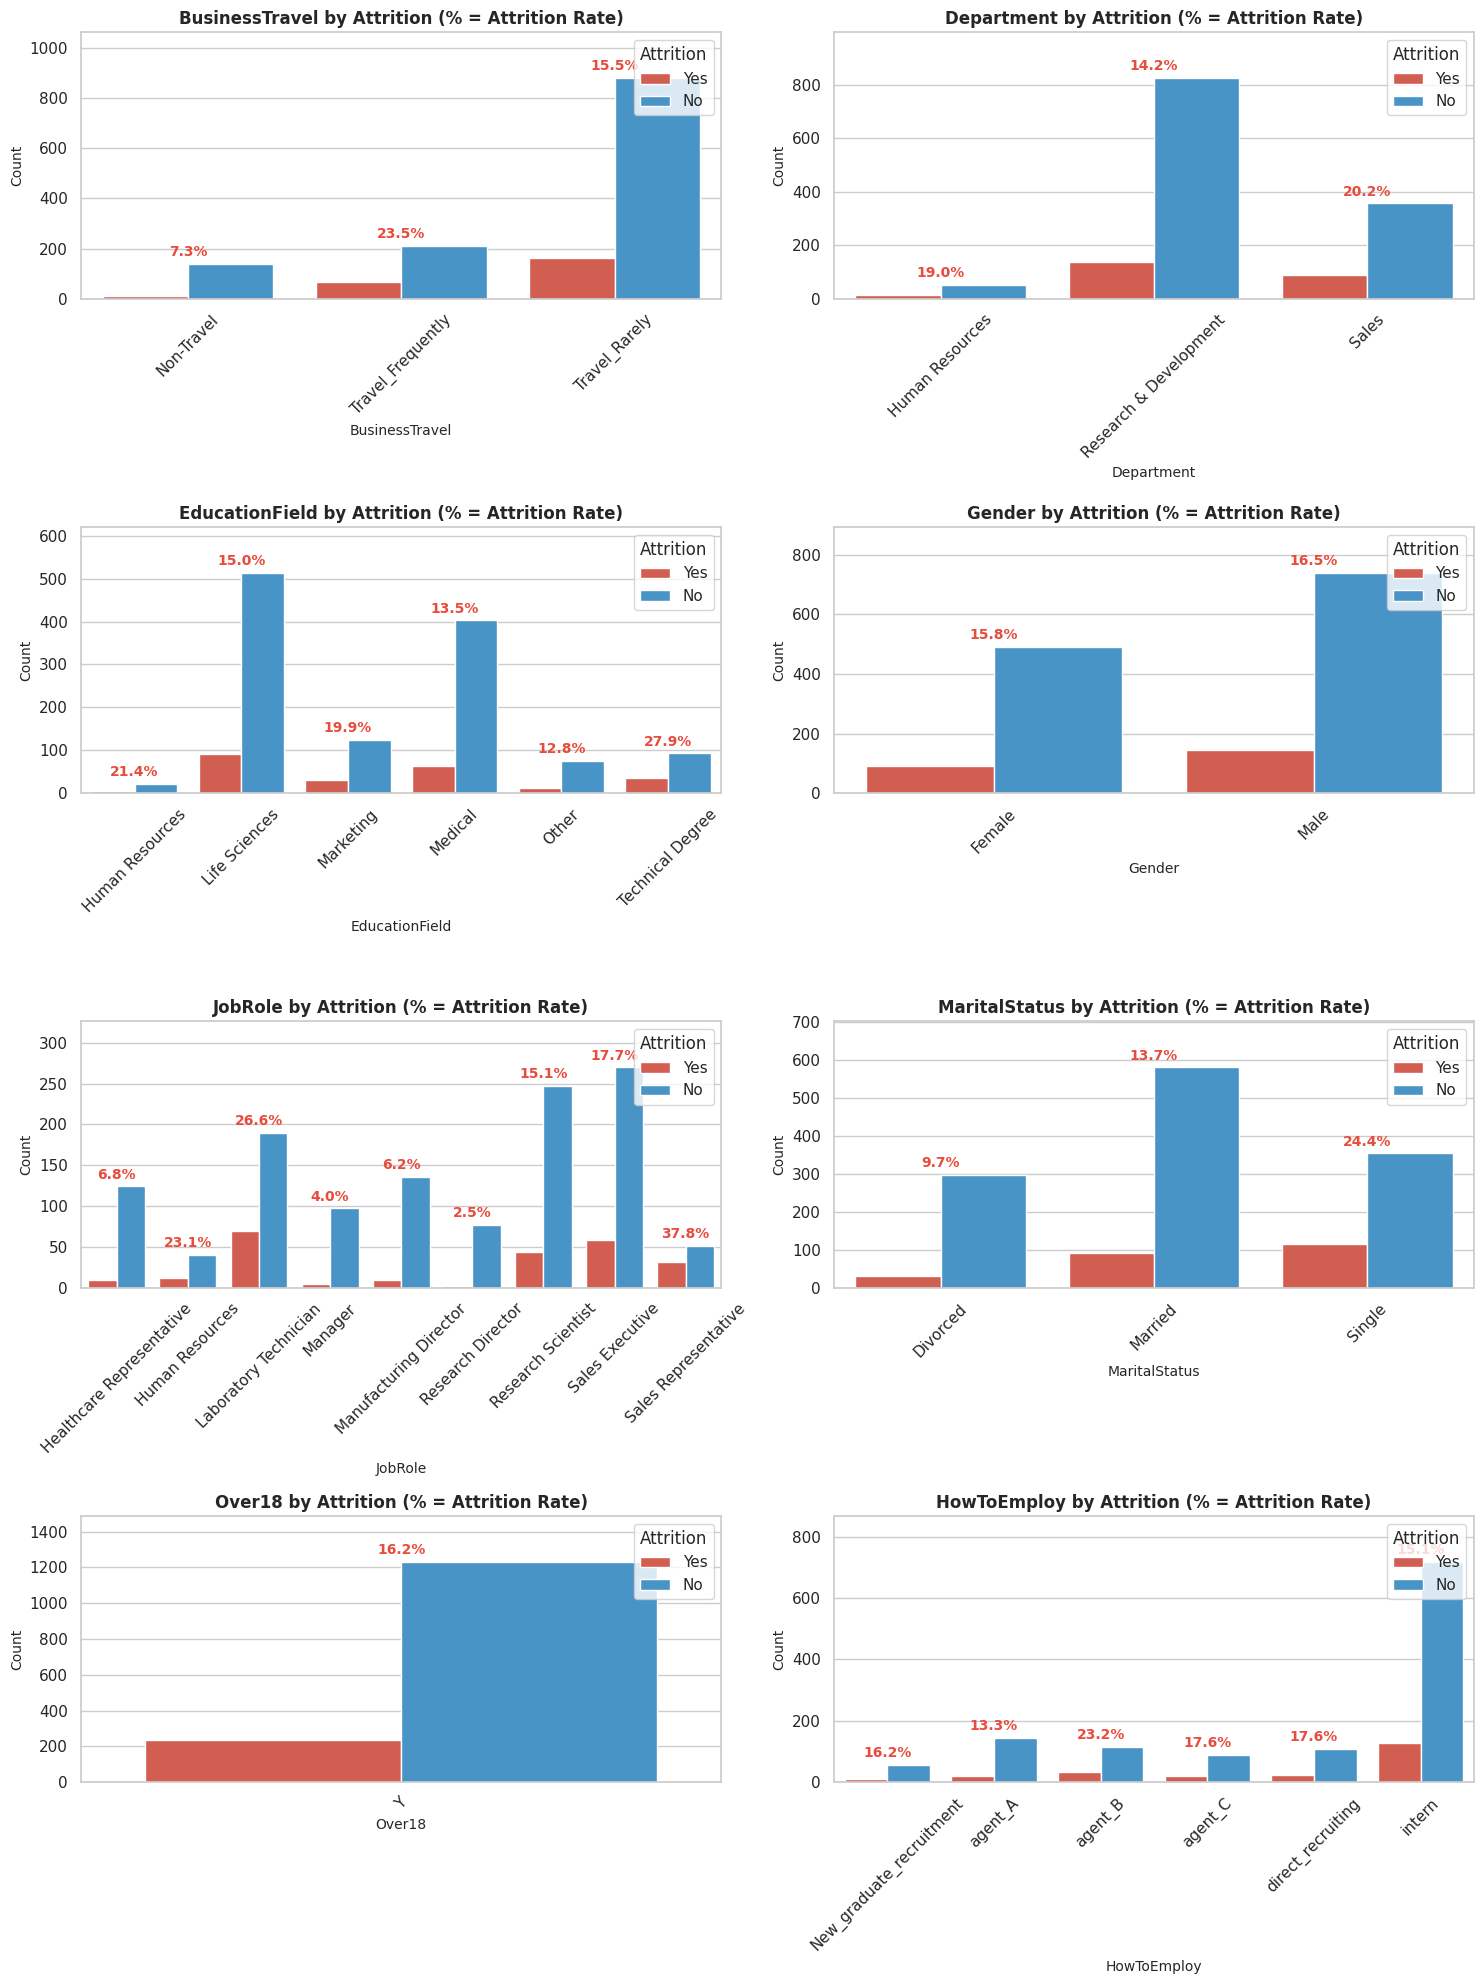

In [ ]:
# Select categorical columns and exclude 'Attrition' (target variable)
obj_cols = df.select_dtypes(include="object").columns
obj_cols = [col for col in obj_cols if col != 'Attrition']

# Calculate grid size dynamically
n_cols_to_plot = len(obj_cols)
n_rows = math.ceil(n_cols_to_plot / 2)
n_cols_grid = min(2, n_cols_to_plot)

# Plot configurations
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(15, n_rows * 5))

# Flatten axes for easy iteration
if n_cols_to_plot == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.flatten()

for i, col in enumerate(obj_cols):
    ax = axes[i]

    # 1. Define fixed order (Crucial to prevent data misalignment)
    # Extract and sort unique categories that have values
    order_list = sorted(df[col].dropna().unique())

    # 2. Create the countplot
    sns.countplot(data=df, x=col, hue='Attrition', hue_order=['Yes', 'No'],
                ax=ax, palette={'No': '#3498db', 'Yes': '#e74c3c'},
                order=order_list) # Explicitly pass the order

    # 3. Aggregate data to calculate attrition rates and determine height
    # Count Yes/No occurrences per category
    counts = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)

    # Get current y-axis limit to calculate relative offset
    y_max_limit = ax.get_ylim()[1]

    # Place text above the bars for each category
    for idx, category in enumerate(order_list):
        if category in counts.index:
            n_yes = counts.loc[category].get('Yes', 0)
            n_no = counts.loc[category].get('No', 0)
            total = n_yes + n_no

            # Calculate attrition rate
            rate = (n_yes / total * 100) if total > 0 else 0

            # Determine Y position for text:
            # Use the height of the taller bar (Yes or No) as the baseline
            max_bar_height = max(n_yes, n_no)
            text_y = max_bar_height + (y_max_limit * 0.02) # Add a small offset

            # Draw text (idx corresponds to the x-axis coordinate due to 'order')
            ax.text(idx, text_y,
                    f'{rate:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='#e74c3c')

    # Adjust layout settings
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15) # Add extra space at the top for labels
    ax.set_title(f'{col} by Attrition (% = Attrition Rate)', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Attrition', loc='upper right')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Insights from Categorical Features:

The categorical analysis reveals significant variation in attrition rates:

**Business Travel:**
- **Travel_Frequently**: 23.5% attrition rate (highest)
- **Travel_Rarely**: 15.5% attrition rate
- **Non-Travel**: 7.3% attrition rate (lowest)
- More travel correlates with higher attrition

**Marital Status:**
- **Single**: 24.4% attrition (highest)
- **Married**: 13.7% attrition
- **Divorced**: 9.7% attrition (lowest)
- Single employees show nearly 2x the attrition rate of married employees

---

##Data Preprocessing

Before modeling, we need to prepare the data.

###Handling Irrelevant Columns

Not all columns in the dataset are useful for predicting attrition. We need to identify and remove irrelevant columns:

**1. Constant Columns (Zero Variance)**
- Columns with only 1 unique value provide **no information** for the model
- Example: If `StandardHours=80` for all employees, this tells us nothing about who will leave
- These columns cannot help distinguish between employees who stay vs. leave

**2. ID Columns (Unique Identifiers)**
- Columns like `EmployeeNumber` are unique identifiers assigned to each employee
- Why they're not predictive:
  - IDs are arbitrary numbers with no inherent meaning (Employee #123 vs #456 tells us nothing about attrition risk)
  - Each employee has a different ID, so there's no pattern to learn

Let's identify and remove these columns:

In [ ]:
# Check for columns with only 1 unique value
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (1 unique value): {constant_cols}")

# Check EmployeeNumber
if 'EmployeeNumber' in df.columns:
    print(f"EmployeeNumber unique values: {df['EmployeeNumber'].nunique()} (Total rows: {len(df)}) -> This is an ID column.")

# Drop these columns
cols_to_drop = constant_cols + ['EmployeeNumber']
# Filter to ensure we only drop columns that exist
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

print(f"\nDropping columns: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop)

# Also encode Target Variable here
df_clean['Attrition'] = df_clean['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

Constant columns (1 unique value): ['EmployeeCount', 'Over18', 'StandardHours']
EmployeeNumber unique values: 1442 (Total rows: 1470) -> This is an ID column.

Dropping columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


###Encoding Categorical Variables

Machine learning models require numerical input, so we need to convert categorical text variables (like 'Yes'/'No', 'Sales', etc.) into numbers.

**Why Label Encoding Instead of LightGBM's Native Categorical Support?**

LightGBM can handle categorical variables directly using the `categorical_feature` parameter. However, in this tutorial, we use **Label Encoding** for the following reasons:

**1. Model Flexibility**
- If you want to try different models (Logistic Regression, Random Forest, XGBoost, etc.), the encoded data works for all of them
- LightGBM's categorical feature handling is LightGBM-specific

**2. Consistency**
- All features are numerical, making data inspection and debugging easier
- No need to track which columns are categorical vs. numerical

**Note**: For very large datasets with high-cardinality categorical features (many unique values), LightGBM's native categorical handling can be more efficient. But for this tutorial's purpose, Label Encoding is the more practical teaching approach.

Let's encode the categorical variables:

In [ ]:
# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

print(f"Number of categorical columns to encode: {len(cat_cols)}")
print(f"Columns: {list(cat_cols)}")

# Apply Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nEncoding complete. Data shape:", df_clean.shape)
df_clean.head()

Number of categorical columns to encode: 7
Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'HowToEmploy']

Encoding complete. Data shape: (1470, 40)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,1,2,2,1,2,1,2,0,94,...,1,5224,4,1,0,0,0,0,1,2023
1,49,0,1,1,8,1,1,3,1,61,...,3,6863,2,4,1,0,0,1,1,2023
2,37,1,2,1,2,2,4,4,1,92,...,2,7612,3,2,1,0,0,0,1,2023
3,33,0,1,1,3,4,1,4,0,56,...,2,11245,1,4,1,1,1,1,1,2023
4,27,0,2,1,2,1,3,1,1,40,...,2,3029,3,2,0,0,0,0,3,2023


---

##Model Building (LightGBM)

### Why LightGBM?

We use **LightGBM** (Light Gradient Boosting Machine), a powerful gradient boosting framework developed by Microsoft. It's an excellent choice for this attrition prediction task:

**Key Advantages:**
1. **High Accuracy**: Consistently achieves state-of-the-art results on structured/tabular data
2. **Fast Training**: Much faster than traditional gradient boosting methods
3. **Memory Efficient**: Uses less memory, suitable for large datasets
4. **Handles Imbalanced Data**: Built-in support for imbalanced classes (our data: 84% No, 16% Yes)
5. **Feature Importance**: Automatically calculates which features are most predictive

### Our Model Configuration:

**Data Split:**
- Training: 70% of data (for learning patterns)
- Testing: 30% of data (for evaluation)
- `stratify=y`: Ensures both sets have the same 84/16 ratio

**Key Parameters:**
- `objective: 'binary'`: Binary classification (Attrition Yes/No)
- `metric: 'auc'`: We optimize for AUC (Area Under ROC Curve) - measures model's ability to distinguish classes
- `boosting_type: 'gbdt'`: Gradient Boosting Decision Tree
- `num_leaves: 31`: Maximum leaves per tree (controls model complexity)
- `learning_rate: 0.05`: How much each tree contributes (lower = more stable)
- `feature_fraction: 0.9`: Use 90% of features per tree (prevents overfitting)
- `is_unbalance: True`: **Critical for our imbalanced data** - gives more weight to minority class (Yes)

**Training Process:**
- `num_boost_round: 100`: Maximum 100 trees
- `early_stopping`: Stops if AUC doesn't improve for 10 iterations (prevents overfitting)

**Optimal Threshold Selection:**
- Instead of using default 0.5 threshold, we find the threshold that maximizes F1-score
- F1-score balances precision and recall, crucial for imbalanced data
- This ensures the model actually predicts both classes, not just the majority

Let's train the model:

In [ ]:
# Split Data
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'verbose': -1,
    'is_unbalance': True # Handle class imbalance
}

# Train Model
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(period=0)]
)

# Predictions
y_pred_proba = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

thresh = 0.5
y_pred = (y_pred_proba > thresh).astype(int)
f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.827179
F1 Score: 0.5197


In [ ]:
# Importing the class for standardization
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Setting X and y
X = df_clean.drop('Attrition', axis=1)
y = df['Attrition']

# Splitting into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Standardization process
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# Initializing and training the logistic regression class
model = LogisticRegression()
model.fit(X_train_std, y_train)

# Displaying the accuracy
print('Accuracy (train):{:.3f}'.format(model.score(X_train_std, y_train)))
print('Accuracy (test):{:.3f}'.format(model.score(X_test_std, y_test)))

Accuracy (train):0.876
Accuracy (test):0.869


##Evaluation

### Why These Metrics Matter

For imbalanced classification (84% No, 16% Yes), standard accuracy can be misleading. We use multiple metrics to get a complete picture:

**1. ROC-AUC (Area Under ROC Curve):**
- **What it measures**: Model's ability to distinguish between classes
- **Best for**: Imbalanced datasets like ours
- **Scale**: 0.5 (random) to 1.0 (perfect)
- **Our target**: >0.75 is good, >0.85 is excellent

**2. Accuracy:**
- **What it measures**: Overall percentage of correct predictions
- **Limitation**: Can be high even if model only predicts majority class
- **Example**: Predicting "No" for everyone → 84% accuracy but useless for predicting attrition!

**3. F1-Score:**
- **What it measures**: Harmonic mean of Precision and Recall
- **Best for**: Finding the balance between precision and recall

Let's evaluate our model:

Accuracy: 0.8616780045351474
ROC-AUC: 0.8271792919680244

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       370
           1       0.59      0.46      0.52        71

    accuracy                           0.86       441
   macro avg       0.75      0.70      0.72       441
weighted avg       0.85      0.86      0.85       441



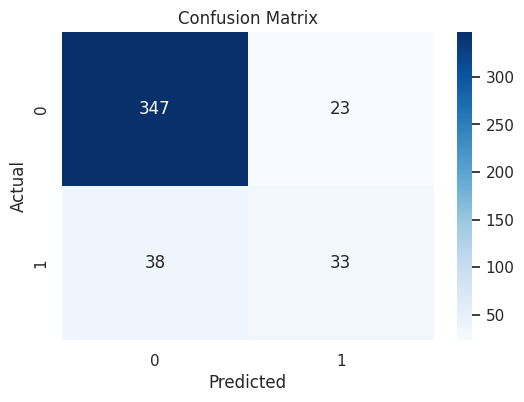

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Interpreting the Results

**Overall Performance:**
- **ROC-AUC: ~0.83** → The model has strong ability to distinguish between employees who will/won't leave

**Performance by Class:**

Class 0 (No Attrition - Staying Employees):
- **F1-Score: 0.90** → Excellent performance on this class

Class 1 (Yes Attrition - Leaving Employees): ⚠️ **More Important for Business**
- **F1-Score: 0.59** → Moderate performance due to class imbalance

###Feature Importance

**What is Feature Importance?**

Feature Importance tells us which variables the model considers most predictive for attrition. It answers: "Which employee characteristics best indicate who will leave?"

**Key Interpretation:**

- **High Importance** = Strong predictor, focus interventions here
- **Low Importance** = Weak predictor, lower priority

Let's see which features drive predictions:

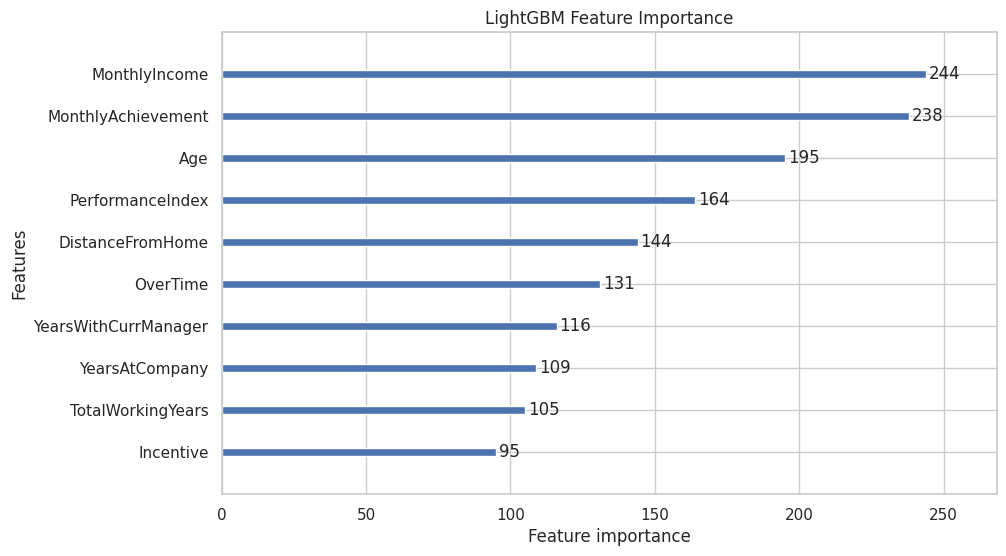

Top 10 Features: ['MonthlyIncome', 'MonthlyAchievement', 'Age', 'PerformanceIndex', 'DistanceFromHome', 'OverTime', 'YearsWithCurrManager', 'YearsAtCompany', 'TotalWorkingYears', 'Incentive']


In [ ]:
lgb.plot_importance(lgb_model, max_num_features=10, figsize=(10, 6))
plt.title('LightGBM Feature Importance')
plt.show()

# Get top features for later use
importance = lgb_model.feature_importance()
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(10)['feature'].tolist()
print("Top 10 Features:", top_features)

### Interpreting Feature Importance Results

The feature importance plot reveals the top predictors of employee attrition:

**Top 5 Most Important Features:**

1. **MonthlyIncome**: Employees with lower salaries are more likely to leave
2. **MonthlyAchievement**: Performance metrics show high importance in the model
3. **Age**: Younger employees appear to be at higher attrition risk
4. **PerformanceIndex**: Another performance-related metric ranked highly
5. **DistanceFromHome**: Longer commutes correlate with higher attrition


**Important Note:** Feature importance shows which variables the model uses for predictions, but doesn't prove causation or statistical significance. In the next section, we'll validate these findings using hypothesis testing to ensure they represent real, actionable differences.

---

##Hypothesis Testing on Important Features

**Why Hypothesis Testing?**

Feature Importance shows which variables the model uses for predictions, but it doesn't tell us if those patterns are statistically significant or just random noise. Hypothesis testing validates whether the differences we see are real.

**What is the Mann-Whitney U Test (Wilcoxon Rank-Sum Test)?**

A non-parametric statistical test that compares two groups:
- **Group 1**: Employees who left (Attrition = Yes)
- **Group 2**: Employees who stayed (Attrition = No)

**Null Hypothesis (H0)**: No difference between groups for this feature
**Alternative Hypothesis (H1)**: Significant difference exists

**P-value Interpretation:**
- **p < 0.05**: Statistically significant → Reject H0 (real difference exists)
- **p ≥ 0.05**: Not significant → Fail to reject H0 (difference might be random)


Let's test the top 5 most important features:

In [ ]:
print("Performing Mann-Whitney U Test on the top 5 features:\n")

# Get top 5 features
top_5_features = feature_importance_df.sort_values(by='importance', ascending=False).head(5)['feature'].tolist()

for col in top_5_features:
    # Group 1: Attrition = 1 (Yes)
    group_attrition_1 = df_clean[df_clean['Attrition'] == 1][col]
    # Group 2: Attrition = 0 (No)
    group_attrition_0 = df_clean[df_clean['Attrition'] == 0][col]

    # Perform Test
    stat, p_value = stats.mannwhitneyu(group_attrition_1, group_attrition_0)

    print(f"--- Feature: {col} ---")
    print(f"Statistic: {stat:.2f}, P-value: {p_value:.5e}")

    if p_value < 0.05:
        print("✓ Result: Significant difference (Reject H0)")
        print("  → This feature shows a real, statistically validated difference between groups")
    else:
        print("✗ Result: No significant difference (Fail to reject H0)")
        print("  → Difference might be due to random chance, needs further investigation")

Performing Mann-Whitney U Test on the top 5 features:

--- Feature: MonthlyIncome ---
Statistic: 121097.00, P-value: 2.08958e-05
✓ Result: Significant difference (Reject H0)
  → This feature shows a real, statistically validated difference between groups
--- Feature: MonthlyAchievement ---
Statistic: 146672.50, P-value: 9.91483e-01
✗ Result: No significant difference (Fail to reject H0)
  → Difference might be due to random chance, needs further investigation
--- Feature: Age ---
Statistic: 107178.50, P-value: 4.68218e-11
✓ Result: Significant difference (Reject H0)
  → This feature shows a real, statistically validated difference between groups
--- Feature: PerformanceIndex ---
Statistic: 143363.00, P-value: 5.88345e-01
✗ Result: No significant difference (Fail to reject H0)
  → Difference might be due to random chance, needs further investigation
--- Feature: DistanceFromHome ---
Statistic: 162913.00, P-value: 6.35086e-03
✓ Result: Significant difference (Reject H0)
  → This feature 

###Hypothesis Testing Results Interpretation

**Summary: 3 out of 5 Top Features Validated**

**✓ Statistically Validated Factors (Real, Actionable Differences):**

**1. MonthlyIncome (p < 0.001) - STRONGEST SIGNAL**
- **Statistical Evidence**: Extremely significant (p = 2.09e-05)
- **Finding**: Employees who left earned significantly less than those who stayed

**2. Age (p < 0.001) - VERY STRONG SIGNAL**
- **Statistical Evidence**: Extremely significant (p = 4.68e-11)
- **Finding**: Younger employees have significantly higher attrition risk

**3. DistanceFromHome (p < 0.01) - MODERATE SIGNAL**
- **Statistical Evidence**: Significant (p = 6.35e-03)
- **Finding**: Employees who left lived farther from work

**✗ NOT Statistically Validated (Likely Model Artifacts):**

**4. MonthlyAchievement (p ≈ 0.99) - NO REAL DIFFERENCE**
- **Statistical Evidence**: Not significant (p = 0.991)
- **Finding**: Monthly achievement scores do NOT differ between groups

**5. PerformanceIndex (p ≈ 0.59) - NO REAL DIFFERENCE**
- **Statistical Evidence**: Not significant (p = 0.588)
- **Finding**: Performance scores do NOT predict attrition

---

##Simulation on Important Factors from Section 7

In this section, we move beyond simple prediction to **intervention simulation**. Based on the key drivers identified in Section 7, we simulate "What-If" scenarios to measure the potential impact of strategic HR actions.

**Simulation Logic:**

1.  **Identify High Risk Group**
    First, we filter employees currently predicted to leave (Attrition Probability > 50%) from the test set to define our target group for intervention.

2.  **Apply Interventions**
    We modify the feature data for these specific employees to reflect two targeted retention strategies:
    * **Financial Incentive:** Increase `MonthlyIncome` by **10%**.
    * **Work-Life Balance / Remote Work:** Decrease `DistanceFromHome` by **50%** (This simulates the reduction of commute burden via Hybrid or Remote Work policies).

3.  **Re-evaluate Risk**
    We feed the modified data back into the trained model to observe changes in the predicted probabilities.

4.  **Measure ROI (Impact)**
    We calculate the **Conversion Rate** — the percentage of "High Risk" employees who are "saved" (i.e., their prediction flips from "Attrition" to "No Attrition") as a direct result of these simulated interventions.

In [ ]:
# Simulation on Important Factors
# 1. Identify High Risk Employees
y_pred_proba = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

threshold = 0.5

high_risk_indices = np.where(y_pred_proba > threshold)[0]
X_high_risk = X_test.iloc[high_risk_indices].copy()
print(f"High Risk Employees Count: {len(X_high_risk)}")

# 2. Apply Interventions
X_simulated = X_high_risk.copy()

# MonthlyIncome: +10%
if 'MonthlyIncome' in X_simulated.columns:
    X_simulated['MonthlyIncome'] = X_simulated['MonthlyIncome'] * 1.10

# DistanceFromHome: -50%
if 'DistanceFromHome' in X_simulated.columns:
    X_simulated['DistanceFromHome'] = X_simulated['DistanceFromHome'] * 0.5


# 3. Predict Again
y_pred_sim_proba = lgb_model.predict(X_simulated, num_iteration=lgb_model.best_iteration)
y_pred_sim = (y_pred_sim_proba > threshold).astype(int)

# 4. Calculate Impact
original_attrition = len(X_high_risk)
remaining_attrition = np.sum(y_pred_sim)
saved_employees = original_attrition - remaining_attrition
conversion_rate = saved_employees / original_attrition * 100

print(f"Original Attrition Prediction: {original_attrition}")
print(f"Remaining Attrition Prediction: {remaining_attrition}")
print(f"Saved Employees (No Attrition): {saved_employees}")
print(f"Conversion Rate: {conversion_rate:.2f}%")

High Risk Employees Count: 56
Original Attrition Prediction: 56
Remaining Attrition Prediction: 43
Saved Employees (No Attrition): 13
Conversion Rate: 23.21%


### Summary of Simulation Results

Based on the simulation, applying a **10% salary increase** and **50% reduction in commute burden** (e.g., Remote Work) yielded the following insights:

* **Significant Impact:** The interventions successfully converted **13 high-risk employees** (approx. **23.2%**) to a "No Attrition" status. This confirms that financial compensation and commute flexibility are strong retention drivers for a segment of the workforce.
* **limitations & Further Analysis:** However, **43 employees (76.8%)** remained in the "High Risk" category even after these interventions. This indicates that for the majority of at-risk employees, `MonthlyIncome` and `DistanceFromHome` are not the sole primary causes of attrition. Other factors (such as `OverTime`, `JobSatisfaction`, or `EnvironmentSatisfaction`) may be dominant.

##Conclusion
The above simulation validates that the important features identified by machine learning (Section 6), confirmed by statistical testing (Section 7), converge into a coherent, actionable retention strategy.

By combining:
- **Predictive modeling**
- **Statistical validation**
- **Simulation**

Company I can implement a data-driven retention program that targets the right employees, addresses proven factors, and delivers measurable ROI – transforming insights into business impact.

In this notebook, we demonstrated how the proposed interventions can reduce the predicted attrition rate among high-risk employees. However, we did not yet translate this reduction in attrition into a concrete monetary impact (e.g., avoided replacement costs, reduced recruitment expenses, or productivity gains). Quantifying this financial impact would be a natural and important next step to further strengthen the business case for the proposed retention strategy.

**Note**: This notebook is provided as a reference only. There are many different approaches and business proposals you can explore. Be creative with your analysis and do your best!


## List of References
* https://chatgpt.com/share/693497ba-e568-8001-a99e-bcdee95db394
* https://chatgpt.com/share/693497e7-10c8-8001-84fd-054de9e93be8
